In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)


In [30]:
df = pd.read_csv("../data/cleaned/sales_cleaned.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df.head()


,Order_Item_ID,Order_ID,Product_ID,Quantity,Discount,Order_Date,Customer_ID,Sales_Channel,Payment_Method,Region_ID,Product_Name,Category,Sub_Category,Unit_Cost,List_Price,Region,Revenue,Cost,Profit,Profit_Margin
0,ITEM0000001,ORD009042,PROD0102,2,0.05,2022-05-21,CUST04933,Online,PayPal,R02,Monitors Product 102,Technology,Monitors,591.01,1029.91,South,1956.829,1182.02,774.809,0.395951
1,ITEM0000002,ORD020217,PROD0064,2,0.15,2025-05-04,CUST02364,Retail,Credit Card,R04,Binders Product 064,Office Supplies,Binders,35.55,62.09,West,105.553,71.10,34.453,0.326405
2,ITEM0000003,ORD012919,PROD0004,3,0.30,2023-10-05,CUST00853,Retail,Credit Card,R05,Laptops Product 004,Technology,Laptops,218.07,336.74,Central,707.154,654.21,52.944,0.074869
3,ITEM0000004,ORD015724,PROD0168,2,0.10,2023-04-16,CUST01937,Online,Credit Card,R02,Tables Product 168,Furniture,Tables,204.07,425.03,South,765.054,408.14,356.914,0.466521
4,ITEM0000005,ORD029803,PROD0070,1,0.15,2022-08-26,CUST00959,Online,Credit Card,R04,Storage Product 070,Furniture,Storage,545.31,1187.10,West,1009.035,545.31,463.725,0.459573


In [31]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()


Rows: 60000
Columns: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_Item_ID   60000 non-null  object        
 1   Order_ID        60000 non-null  object        
 2   Product_ID      60000 non-null  object        
 3   Quantity        60000 non-null  int64         
 4   Discount        60000 non-null  float64       
 5   Order_Date      60000 non-null  datetime64[ns]
 6   Customer_ID     59925 non-null  object        
 7   Sales_Channel   60000 non-null  object        
 8   Payment_Method  60000 non-null  object        
 9   Region_ID       60000 non-null  object        
 10  Product_Name    60000 non-null  object        
 11  Category        60000 non-null  object        
 12  Sub_Category    60000 non-null  object        
 13  Unit_Cost       60000 non-null  float64       
 14  List_Price      60000 non-null

In [32]:
df.describe()


,Quantity,Discount,Order_Date,Unit_Cost,List_Price,Revenue,Cost,Profit,Profit_Margin
count,60000.000000,60000.000000,60000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,2.613483,0.092329,2023-12-29 12:39:50.400000256,412.192949,704.823342,1673.167440,1077.631806,595.535634,0.326418
min,1.000000,0.000000,2022-01-01 00:00:00,16.360000,27.640000,19.348000,16.360000,-658.410000,-0.222597
25%,1.000000,0.000000,2022-12-28 00:00:00,226.670000,358.170000,590.461000,401.440000,139.989000,0.235873
50%,2.000000,0.100000,2023-12-28 00:00:00,415.630000,692.280000,1109.153500,725.110000,347.980000,0.348590
75%,4.000000,0.150000,2024-12-25 00:00:00,581.240000,1042.140000,2194.072500,1450.220000,762.420000,0.436097
max,8.000000,0.300000,2025-12-31 00:00:00,796.880000,1664.580000,12583.280000,6375.040000,6546.080000,0.544842
std,1.782996,0.079560,NaN,220.343407,404.555983,1648.254094,1017.353340,717.449027,0.139452


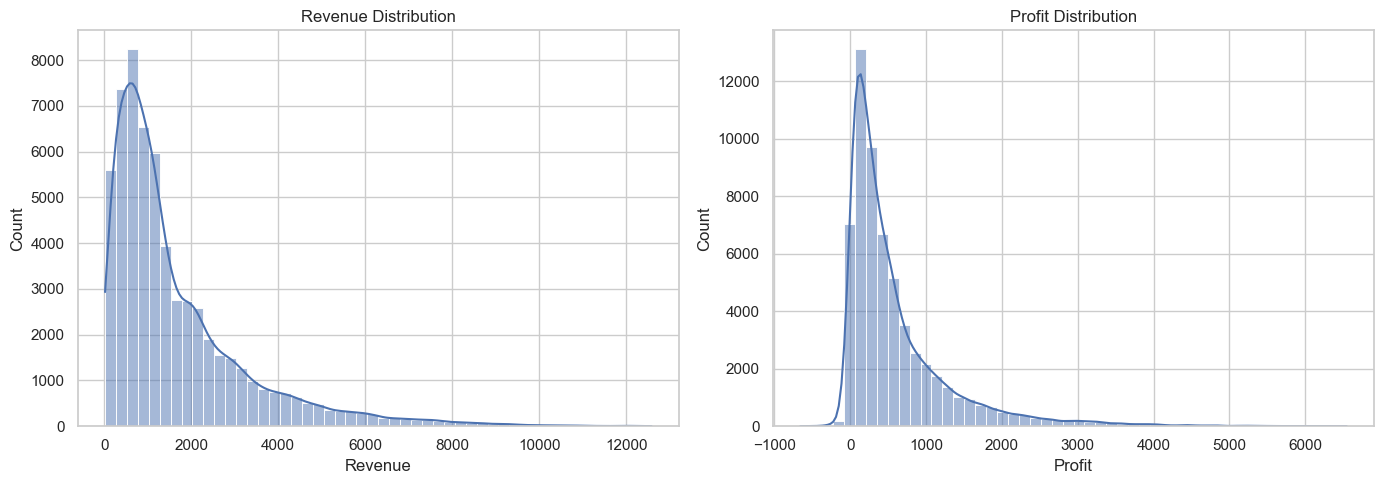

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Revenue"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Revenue Distribution")
axes[0].set_xlabel("Revenue")

sns.histplot(
    df["Profit"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")

plt.tight_layout()
plt.show()


In [34]:
negative_profit = df[df["Profit"] < 0]

print(
    "Transactions with negative profit:",
    len(negative_profit)
)

print(
    "Percentage:",
    round(
        100 * len(negative_profit) / len(df),
        2
    ),
    "%"
)


Transactions with negative profit: 1147
Percentage: 1.91 %


In [35]:
monthly = (
    df.groupby(
        df["Order_Date"].dt.to_period("M")
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly["Order_Date"] = monthly["Order_Date"].dt.to_timestamp()

monthly.head()


,Order_Date,Revenue,Profit
0,2022-01-01,2.075848e+06,745400.4415
1,2022-02-01,1.750506e+06,625344.6640
2,2022-03-01,2.086766e+06,738389.6650
3,2022-04-01,2.265926e+06,796100.0040
4,2022-05-01,2.171568e+06,777131.2975


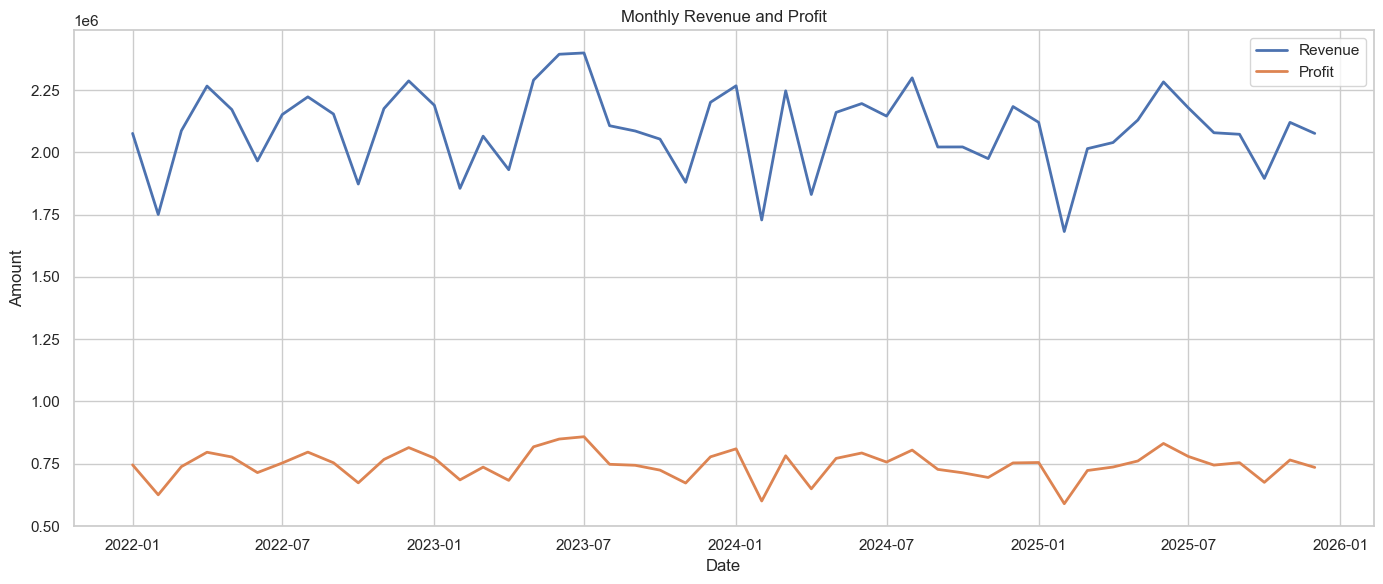

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["Order_Date"],
    monthly["Revenue"],
    label="Revenue",
    linewidth=2
)

plt.plot(
    monthly["Order_Date"],
    monthly["Profit"],
    label="Profit",
    linewidth=2
)

plt.title("Monthly Revenue and Profit")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()

plt.tight_layout()
plt.show()


In [37]:
category_performance = (
    df.groupby("Category")
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Units=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

category_performance


,Revenue,Profit,Units
Category,,,
Home,2.723307e+07,9.636811e+06,42078
Furniture,2.526963e+07,8.936605e+06,37488
Technology,2.407744e+07,8.144017e+06,40383
Office Supplies,2.380991e+07,9.014705e+06,36860


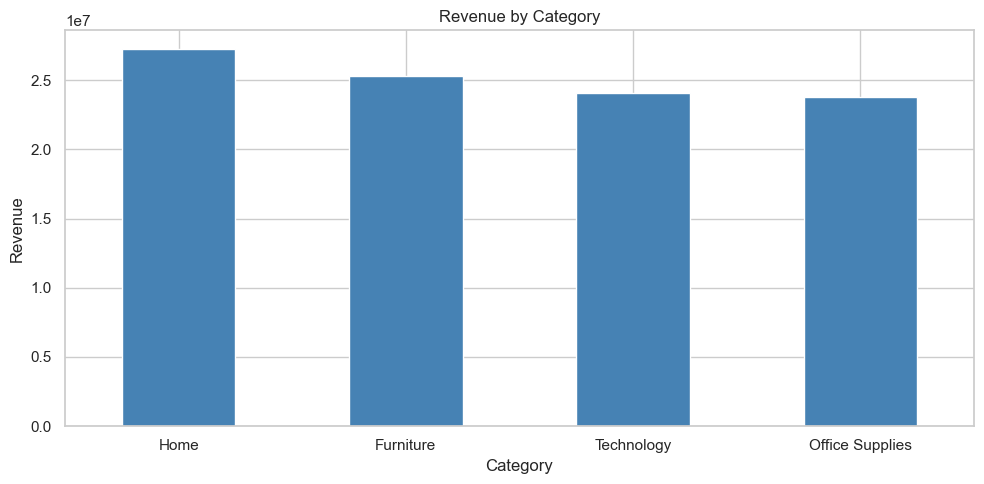

In [38]:
category_performance["Revenue"].plot(
    kind="bar",
    figsize=(10, 5),
    color="steelblue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [39]:
category_performance["Profit_Margin"] = (
    category_performance["Profit"]
    / category_performance["Revenue"]
)

category_performance


,Revenue,Profit,Units,Profit_Margin
Category,,,,
Home,2.723307e+07,9.636811e+06,42078,0.353864
Furniture,2.526963e+07,8.936605e+06,37488,0.353650
Technology,2.407744e+07,8.144017e+06,40383,0.338243
Office Supplies,2.380991e+07,9.014705e+06,36860,0.378612


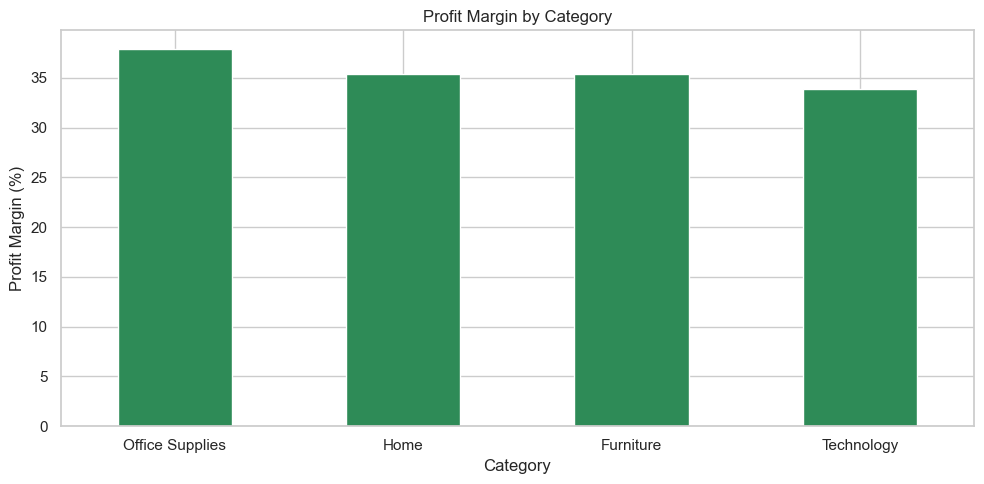

In [40]:
(
    category_performance["Profit_Margin"]
    .sort_values(ascending=False)
    .mul(100)
    .plot(
        kind="bar",
        figsize=(10, 5),
        color="seagreen"
    )
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [41]:
yearly = (
    df.groupby(df["Order_Date"].dt.year)
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
    .reset_index()
)

yearly = yearly.rename(columns={"Order_Date": "Year"})

yearly["Profit_Margin"] = (
    yearly["Profit"] / yearly["Revenue"] * 100
)


In [42]:
yearly["Profit_Margin"] = (
    yearly["Profit"] / yearly["Revenue"] * 100
)

yearly


,Year,Revenue,Profit,Orders,Customers,Profit_Margin
0,2022,2.517884e+07,8.955492e+06,6531,3653,35.567529
1,2023,2.544712e+07,9.069261e+06,6436,3640,35.639634
2,2024,2.507437e+07,8.857095e+06,6562,3675,35.323297
3,2025,2.468971e+07,8.850290e+06,6437,3628,35.846066


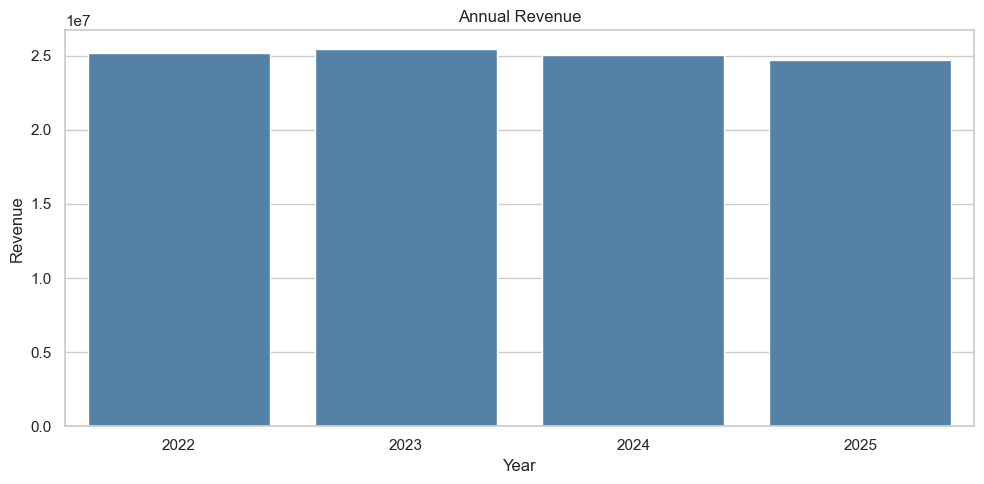

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly,
    x="Year",
    y="Revenue",
    color="steelblue"
)

plt.title("Annual Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()


In [ ]:
region_performance = (
    df.groupby("Region")
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

region_performance["Profit_Margin"] = (
    region_performance["Profit"]
    / region_performance["Revenue"]
    * 100
)

region_performance


In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_performance.reset_index(),
    x="Region",
    y="Revenue",
    color="cornflowerblue"
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
channel_performance = (
    df.groupby("Sales_Channel")
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
)

channel_performance["Profit_Margin"] = (
    channel_performance["Profit"]
    / channel_performance["Revenue"]
    * 100
)

channel_performance


In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_performance.reset_index(),
    x="Sales_Channel",
    y="Revenue",
    color="teal"
)

plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()


In [ ]:
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 1],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "30%+"
    ]
)


In [ ]:
discount_analysis = (
    df.groupby("Discount_Band", observed=True)
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order_Item_ID", "count")
    )
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Profit"]
    / discount_analysis["Revenue"]
    * 100
)

discount_analysis


In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=discount_analysis.reset_index(),
    x="Discount_Band",
    y="Profit_Margin",
    color="darkorange"
)

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()


In [ ]:
numeric_cols = [
    "Quantity",
    "Discount",
    "Unit_Cost",
    "List_Price",
    "Revenue",
    "Cost",
    "Profit",
    "Profit_Margin"
]

correlation = df[numeric_cols].corr()

correlation


In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [56]:
# ==========================================
# NEGATIVE PROFIT ANALYSIS
# ==========================================

negative_profit = df[df["Profit"] < 0].copy()

# Make sure Discount_Band exists
negative_profit["Discount_Band"] = pd.cut(
    negative_profit["Discount"],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 1],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "30%+"
    ]
)

print("===== NEGATIVE PROFIT SUMMARY =====")
print("Transactions:", len(negative_profit))
print(
    "Percentage:",
    round(100 * len(negative_profit) / len(df), 2),
    "%"
)


===== NEGATIVE PROFIT SUMMARY =====
Transactions: 1147
Percentage: 1.91 %


In [48]:
loss_by_category = (
    negative_profit
    .groupby("Category")
    .agg(
        Loss_Transactions=("Order_Item_ID", "count"),
        Total_Loss=("Profit", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Total_Loss")
)

loss_by_category["Loss_Transaction_%"] = (
    loss_by_category["Loss_Transactions"]
    / len(negative_profit)
    * 100
)

print("===== NEGATIVE PROFIT BY CATEGORY =====")
display(loss_by_category)


===== NEGATIVE PROFIT BY CATEGORY =====


,Loss_Transactions,Total_Loss,Revenue,Loss_Transaction_%
Category,,,,
Furniture,301,-22744.5615,323167.3585,26.242371
Home,322,-18570.1980,262442.3720,28.073235
Technology,351,-17557.0830,229348.4770,30.601569
Office Supplies,173,-4554.2970,78936.0030,15.082825


In [49]:
loss_by_region = (
    negative_profit
    .groupby("Region")
    .agg(
        Loss_Transactions=("Order_Item_ID", "count"),
        Total_Loss=("Profit", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Total_Loss")
)

loss_by_region["Loss_Transaction_%"] = (
    loss_by_region["Loss_Transactions"]
    / len(negative_profit)
    * 100
)

print("===== NEGATIVE PROFIT BY REGION =====")
display(loss_by_region)


===== NEGATIVE PROFIT BY REGION =====


,Loss_Transactions,Total_Loss,Revenue,Loss_Transaction_%
Region,,,,
West,254,-15299.1205,200322.0695,22.144725
East,267,-14857.3970,208134.4430,23.278117
North,263,-13691.3745,208753.5755,22.929381
South,220,-13370.8370,180412.6530,19.180471
Central,143,-6207.4105,96271.4695,12.467306


In [50]:
loss_by_channel = (
    negative_profit
    .groupby("Sales_Channel")
    .agg(
        Loss_Transactions=("Order_Item_ID", "count"),
        Total_Loss=("Profit", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Total_Loss")
)

loss_by_channel["Loss_Transaction_%"] = (
    loss_by_channel["Loss_Transactions"]
    / len(negative_profit)
    * 100
)

print("===== NEGATIVE PROFIT BY CHANNEL =====")
display(loss_by_channel)


===== NEGATIVE PROFIT BY CHANNEL =====


,Loss_Transactions,Total_Loss,Revenue,Loss_Transaction_%
Sales_Channel,,,,
Online,715,-40161.3935,546336.9665,62.33653
Retail,432,-23264.7460,347557.2440,37.66347


In [57]:
loss_by_discount = (
    negative_profit
    .groupby("Discount_Band", observed=True)
    .agg(
        Loss_Transactions=("Order_Item_ID", "count"),
        Total_Loss=("Profit", "sum"),
        Revenue=("Revenue", "sum")
    )
)

loss_by_discount["Loss_Transaction_%"] = (
    loss_by_discount["Loss_Transactions"]
    / len(negative_profit)
    * 100
)

print("===== NEGATIVE PROFIT BY DISCOUNT =====")
display(loss_by_discount)


===== NEGATIVE PROFIT BY DISCOUNT =====


,Loss_Transactions,Total_Loss,Revenue,Loss_Transaction_%
Discount_Band,,,,
11-20%,487,-13460.7565,346426.5835,42.458588
21-30%,660,-49965.3830,547467.6270,57.541412


In [52]:
loss_by_product = (
    negative_profit
    .groupby("Product_Name")
    .agg(
        Loss_Transactions=("Order_Item_ID", "count"),
        Total_Loss=("Profit", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Total_Loss")
)

print("===== TOP LOSS-MAKING PRODUCTS =====")
display(loss_by_product.head(10))


===== TOP LOSS-MAKING PRODUCTS =====


,Loss_Transactions,Total_Loss,Revenue
Product_Name,,,
Desks Product 003,87,-7600.7875,115954.7625
Lighting Product 135,35,-5100.2340,53493.6860
Kitchen Product 181,42,-4334.2060,46171.9040
Monitors Product 023,44,-3572.0260,32676.1340
Accessories Product 158,44,-3380.8640,35454.6360
Decor Product 041,47,-2921.1210,37382.4390
Chairs Product 022,13,-2863.8960,23380.6440
Laptops Product 144,35,-2387.8300,34663.3700
Storage Product 133,41,-2245.3600,30895.2800


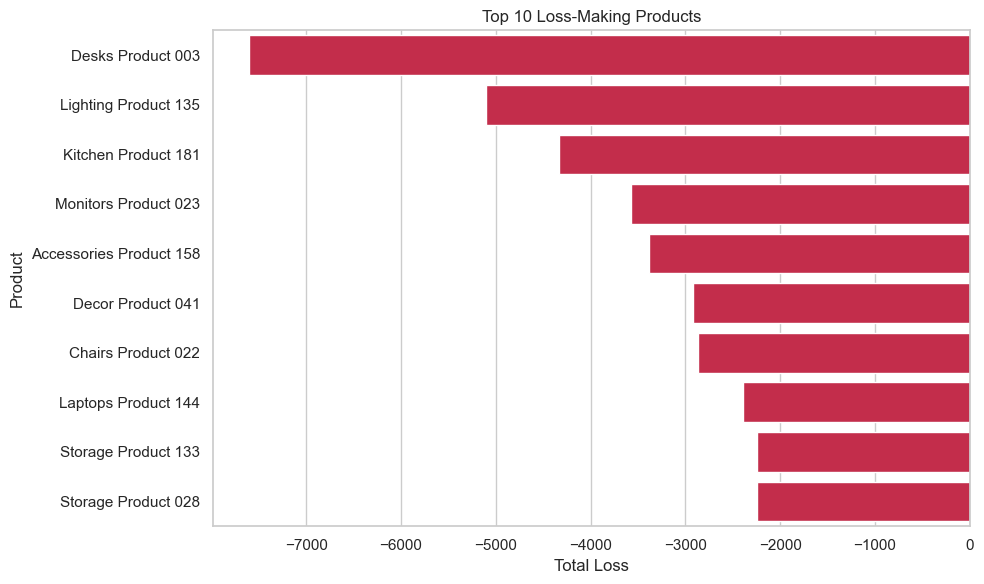

In [53]:
top_loss_products = loss_by_product.head(10).sort_values("Total_Loss")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_loss_products.reset_index(),
    x="Total_Loss",
    y="Product_Name",
    color="crimson"
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Loss")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


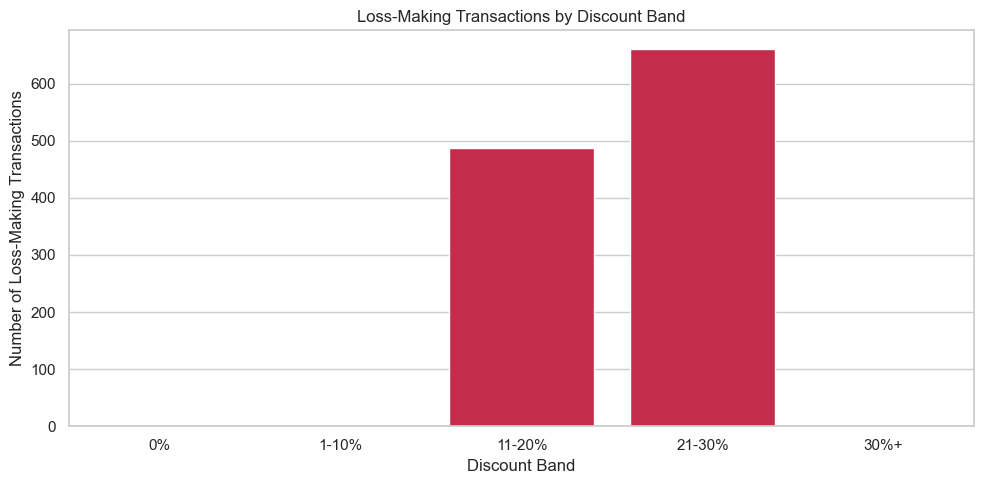

In [58]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=negative_profit,
    x="Discount_Band",
    color="crimson"
)

plt.title("Loss-Making Transactions by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Number of Loss-Making Transactions")

plt.tight_layout()
plt.show()


In [62]:
# ==========================================
# LOSS RATE BY DISCOUNT BAND
# ==========================================

df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 1],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "30%+"
    ]
)

loss_discount_summary = (
    df.groupby("Discount_Band", observed=True)
    .agg(
        Transactions=("Order_Item_ID", "count"),
        Negative_Profit_Transactions=(
            "Profit",
            lambda x: (x < 0).sum()
        )
    )
)

loss_discount_summary["Loss_Rate_%"] = (
    loss_discount_summary["Negative_Profit_Transactions"]
    / loss_discount_summary["Transactions"]
    * 100
)

print("===== LOSS RATE BY DISCOUNT BAND =====")
display(loss_discount_summary)


===== LOSS RATE BY DISCOUNT BAND =====


,Transactions,Negative_Profit_Transactions,Loss_Rate_%
Discount_Band,,,
0%,15158,0,0.000000
1-10%,26867,0,0.000000
11-20%,15008,487,3.244936
21-30%,2967,660,22.244692
